---
title: "Evaluating Region-Focused Preprocessing at Different Anatomical Scales"
format:
    html: 
        code-fold: false
---

## Imports

In [48]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [15]:
# Set the base path for the image folders
base_path = "../data/processed/stage3_disease/images"

# Load one image and convert it to grayscale numpy array
def load_image(folder, index=0):
    files = sorted(os.listdir(os.path.join(base_path, folder)))
    img_path = os.path.join(base_path, folder, files[index])
    img = Image.open(img_path).convert("L")
    return np.array(img), files[index]

# Keep the full image as the baseline preprocessing
def preprocess_full(img):
    return img

# Crop the main dental region using fixed image proportions
def preprocess_roi(img):
    h, w = img.shape
    top = int(0.25 * h)
    bottom = int(0.85 * h)
    left = int(0.18 * w)
    right = int(0.82 * w)
    roi = img[top:bottom, left:right]
    return roi

# # Split the dental ROI into four quadrants
def preprocess_quadrants(img):
    roi = preprocess_roi(img)
    h, w = roi.shape
    mid_h = h // 2
    mid_w = w // 2
    
    # Upper-left
    q1 = roi[:mid_h, :mid_w]  
    # Upper-right 
    q2 = roi[:mid_h, mid_w:]   
    # Lower-left
    q3 = roi[mid_h:, :mid_w]   
    # Lower-right
    q4 = roi[mid_h:, mid_w:]   
    
    return q1, q2, q3, q4

# Show one image with a title
def show_image(img, title="", cmap="gray"):
    plt.figure(figsize=(8, 4))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

# Show the ROI crop box on the original image
def show_roi_box(img):
    h, w = img.shape
    top = int(0.25 * h)
    bottom = int(0.85 * h)
    left = int(0.18 * w)
    right = int(0.82 * w)
    plt.figure(figsize=(10, 5))
    plt.imshow(img, cmap="gray")
    xs = [left, right, right, left, left]
    ys = [top, top, bottom, bottom, top]
    plt.plot(xs, ys, linewidth=2)
    plt.title("Original Image with Dental ROI Box")
    plt.axis("off")
    plt.show()


In [16]:
# Load one sample image for preprocessing check
img, filename = load_image("train", index=0)
print("Sample image:", filename)
print("Original shape:", img.shape)

Sample image: train_0.png
Original shape: (1316, 2850)


In [17]:
# Apply full image, ROI crop, and quadrant preprocessing
full_img = preprocess_full(img)
roi_img = preprocess_roi(img)
q1, q2, q3, q4 = preprocess_quadrants(img)
# Check shape
print("Full image shape:", full_img.shape)
print("ROI shape:", roi_img.shape)
print("Quadrant 1 shape:", q1.shape)
print("Quadrant 2 shape:", q2.shape)
print("Quadrant 3 shape:", q3.shape)
print("Quadrant 4 shape:", q4.shape)

Full image shape: (1316, 2850)
ROI shape: (789, 1824)
Quadrant 1 shape: (394, 912)
Quadrant 2 shape: (394, 912)
Quadrant 3 shape: (395, 912)
Quadrant 4 shape: (395, 912)


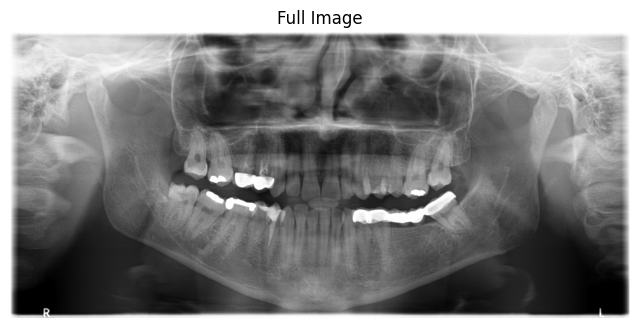

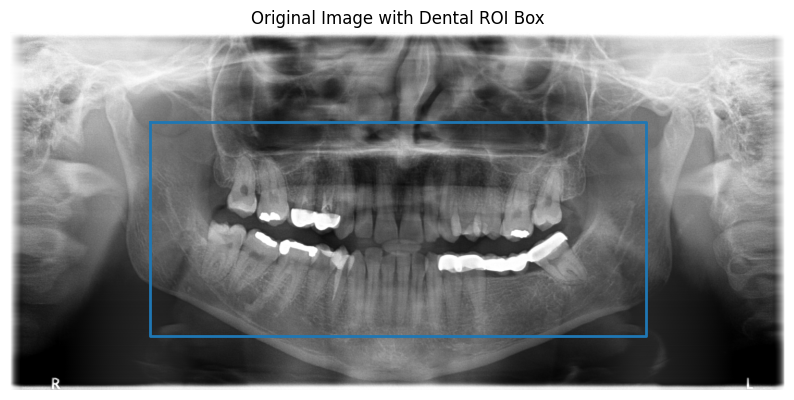

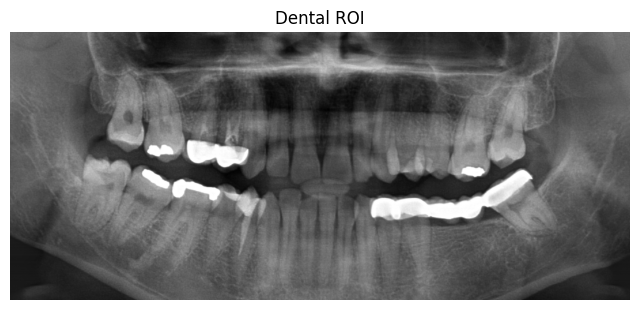

In [18]:
# Visualize the original image and the ROI box
show_image(full_img, "Full Image")
show_roi_box(full_img)
show_image(roi_img, "Dental ROI")

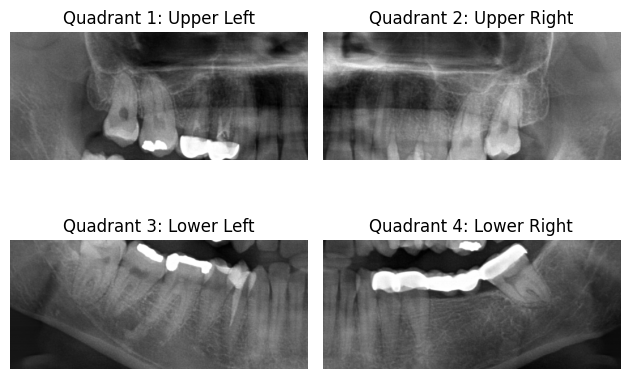

In [19]:
# Visualize the four quadrants
fig, axes = plt.subplots(2, 2)

axes[0, 0].imshow(q1, cmap="gray")
axes[0, 0].set_title("Quadrant 1: Upper Left")
axes[0, 0].axis("off")

axes[0, 1].imshow(q2, cmap="gray")
axes[0, 1].set_title("Quadrant 2: Upper Right")
axes[0, 1].axis("off")

axes[1, 0].imshow(q3, cmap="gray")
axes[1, 0].set_title("Quadrant 3: Lower Left")
axes[1, 0].axis("off")

axes[1, 1].imshow(q4, cmap="gray")
axes[1, 1].set_title("Quadrant 4: Lower Right")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

Dataset Loader

In [20]:
# Define image transforms (resize + normalize)
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Custom dataset class for your project
class DentalDataset(Dataset):
    
    def __init__(self, image_dir, label_dir, mode="full", transform=None):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.mode = mode
        self.transform = transform
        
        self.image_files = sorted(os.listdir(image_dir))
    
    def __len__(self):
        return len(self.image_files)
    
    def get_label(self, label_path):
        # If label file is empty → no object → class 0
        if os.path.getsize(label_path) == 0:
            return 0
        
        # If there is at least one line → object exists → class 1
        return 1
    
    def __getitem__(self, idx):
        filename = self.image_files[idx]
        
        img_path = os.path.join(self.image_dir, filename)
        label_name = os.path.splitext(filename)[0] + ".txt"
        label_path = os.path.join(self.label_dir, label_name)
        
        # Load image
        img = Image.open(img_path).convert("L")
        img = np.array(img)
        
        # Get label
        label = self.get_label(label_path)
        
        # Apply preprocessing mode
        if self.mode == "full":
            processed = preprocess_full(img)
            processed = self.transform(processed)
            return processed, label
        
        elif self.mode == "roi":
            processed = preprocess_roi(img)
            processed = self.transform(processed)
            return processed, label
        
        elif self.mode == "quadrant":
            q1, q2, q3, q4 = preprocess_quadrants(img)
            
            q1 = self.transform(q1)
            q2 = self.transform(q2)
            q3 = self.transform(q3)
            q4 = self.transform(q4)
            
            # Return 4 images + 1 label
            return (q1, q2, q3, q4), label

In [21]:
train_img = "../data/processed/stage3_disease/images/train"
train_lbl = "../data/processed/stage3_disease/labels/train"

val_img = "../data/processed/stage3_disease/images/val"
val_lbl = "../data/processed/stage3_disease/labels/val"

test_img = "../data/processed/stage3_disease/images/test"
test_lbl = "../data/processed/stage3_disease/labels/test"

In [22]:
# Create dataset instances
train_dataset_full = DentalDataset(train_img, train_lbl, mode="full", transform=transform)
train_dataset_roi = DentalDataset(train_img, train_lbl, mode="roi", transform=transform)
train_dataset_quad = DentalDataset(train_img, train_lbl, mode="quadrant", transform=transform)

## Model setup

Create dataloaders

In [58]:
# Create validation and test datasets
val_dataset_full = DentalDataset(val_img, val_lbl, mode="full", transform=transform)
val_dataset_roi = DentalDataset(val_img, val_lbl, mode="roi", transform=transform)
val_dataset_quad = DentalDataset(val_img, val_lbl, mode="quadrant", transform=transform)
test_dataset_full = DentalDataset(test_img, test_lbl, mode="full", transform=transform)
test_dataset_roi = DentalDataset(test_img, test_lbl, mode="roi", transform=transform)
test_dataset_quad = DentalDataset(test_img, test_lbl, mode="quadrant", transform=transform)

# Create dataloaders for full image mode
train_loader_full = DataLoader(train_dataset_full, batch_size=16, shuffle=True)
val_loader_full = DataLoader(val_dataset_full, batch_size=16, shuffle=False)
test_loader_full = DataLoader(test_dataset_full, batch_size=16, shuffle=False)

# Create dataloaders for ROI mode
train_loader_roi = DataLoader(train_dataset_roi, batch_size=16, shuffle=True)
val_loader_roi = DataLoader(val_dataset_roi, batch_size=16, shuffle=False)
test_loader_roi = DataLoader(test_dataset_roi, batch_size=16, shuffle=False)

# Create dataloaders for quadrant mode
train_loader_quad = DataLoader(train_dataset_quad, batch_size=16, shuffle=True)
val_loader_quad = DataLoader(val_dataset_quad, batch_size=16, shuffle=False)
test_loader_quad = DataLoader(test_dataset_quad, batch_size=16, shuffle=False)

Define one CNN model

In [59]:
# Set device for training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [32]:
# Define a simple CNN for binary classification
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.fc2 = nn.Linear(128, 1)
    
    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

Define weighted loss

In [36]:
train_loader_full = DataLoader(train_dataset_full, batch_size=16, shuffle=True)

In [33]:
# Define binary classification loss
criterion = nn.BCEWithLogitsLoss()

# Create one model and optimizer
model = SimpleCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [37]:
# Check one batch from the full-image dataloader
images, labels = next(iter(train_loader_full))

images = images.to(device)
labels = labels.float().unsqueeze(1).to(device)

outputs = model(images)

print("Input batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Output batch shape:", outputs.shape)

Input batch shape: torch.Size([16, 1, 224, 224])
Label batch shape: torch.Size([16, 1])
Output batch shape: torch.Size([16, 1])


## Training

Training loop

In [38]:
# Training function
def train_model(model, train_loader, val_loader, epochs=10):
    
    train_losses = []
    val_losses = []
    
    best_val_loss = float("inf")
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        # Training loop
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            
            optimizer.zero_grad()
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)
        
        # Validation loop
        model.eval()
        val_loss_total = 0.0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.float().unsqueeze(1).to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss_total += loss.item()
        
        val_loss = val_loss_total / len(val_loader)
        val_losses.append(val_loss)
        
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_model.pth")
    
    return train_losses, val_losses

Run training (FULL IMAGE first)

In [40]:
# Create validation dataset
val_dataset_full = DentalDataset(val_img, val_lbl, mode="full", transform=transform)

# Create validation dataloader
from torch.utils.data import DataLoader
val_loader_full = DataLoader(val_dataset_full, batch_size=16, shuffle=False)

In [41]:
model = SimpleCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses_full, val_losses_full = train_model(
    model,
    train_loader_full,
    val_loader_full,
    epochs=10
)

Epoch 1/10
Train Loss: 0.2242 | Val Loss: 0.2686
Epoch 2/10
Train Loss: 0.1690 | Val Loss: 0.2633
Epoch 3/10
Train Loss: 0.1655 | Val Loss: 0.2327
Epoch 4/10
Train Loss: 0.1652 | Val Loss: 0.2378
Epoch 5/10
Train Loss: 0.1707 | Val Loss: 0.2759
Epoch 6/10
Train Loss: 0.1620 | Val Loss: 0.2398
Epoch 7/10
Train Loss: 0.1523 | Val Loss: 0.2406
Epoch 8/10
Train Loss: 0.1573 | Val Loss: 0.2397
Epoch 9/10
Train Loss: 0.1480 | Val Loss: 0.2511
Epoch 10/10
Train Loss: 0.1306 | Val Loss: 0.3150


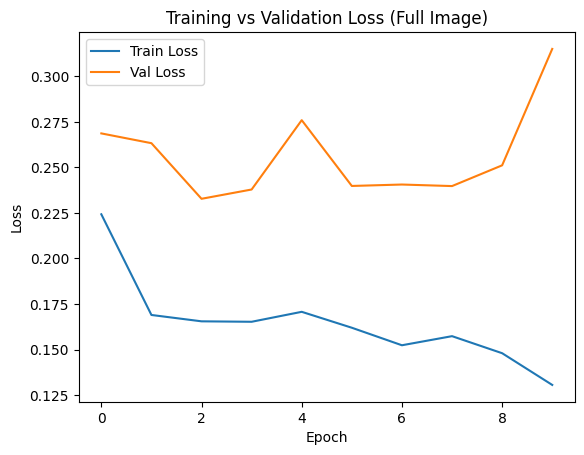

In [42]:
plt.plot(train_losses_full, label="Train Loss")
plt.plot(val_losses_full, label="Val Loss")
plt.legend()
plt.title("Training vs Validation Loss (Full Image)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## evaluate the full-image model on the clean test set.

In [50]:
# Load the best saved model
best_model = SimpleCNN().to(device)
best_model.load_state_dict(torch.load("best_model.pth", map_location=device))
best_model.eval()

C:\Users\Drago\AppData\Local\Temp\ipykernel_21236\1362396172.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load("best_model.pth", map_

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=50176, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

Evaluation function

In [51]:
# Evaluate a trained model on a dataloader
def evaluate_model(model, data_loader):
    model.eval()
    
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).int().squeeze(1)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))
    
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, zero_division=0))
    
    return acc, prec, rec, f1

In [53]:
# Create test dataset
test_dataset_full = DentalDataset(test_img, test_lbl, mode="full", transform=transform)

# Create test dataloader
from torch.utils.data import DataLoader
test_loader_full = DataLoader(test_dataset_full, batch_size=16, shuffle=False)

In [54]:
# Evaluate the best full-image model on the clean test set
acc_full, prec_full, rec_full, f1_full = evaluate_model(best_model, test_loader_full)

Accuracy : 0.988
Precision: 0.988
Recall   : 1.0
F1-score : 0.994

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.99      1.00      0.99       247

    accuracy                           0.99       250
   macro avg       0.49      0.50      0.50       250
weighted avg       0.98      0.99      0.98       250



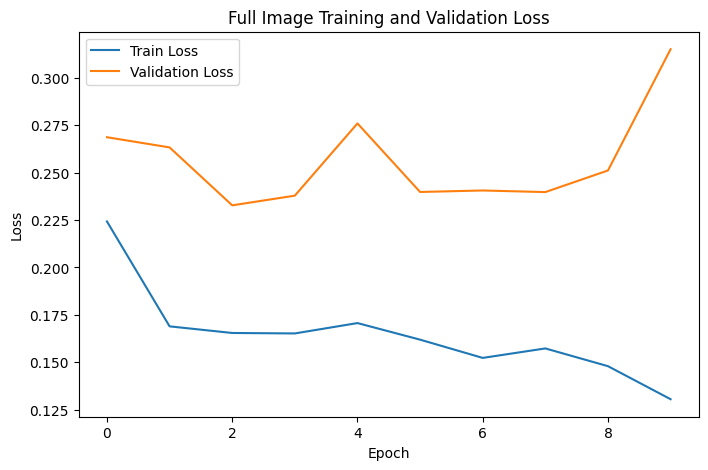

In [55]:
# Plot training and validation loss for the full-image model
plt.figure(figsize=(8, 5))
plt.plot(train_losses_full, label="Train Loss")
plt.plot(val_losses_full, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Full Image Training and Validation Loss")
plt.legend()
plt.show()

### Train ROI model

In [60]:
model_roi = SimpleCNN().to(device)
optimizer = torch.optim.Adam(model_roi.parameters(), lr=0.001)

train_losses_roi, val_losses_roi = train_model(
    model_roi,
    train_loader_roi,
    val_loader_roi,
    epochs=10
)

Epoch 1/10
Train Loss: 0.2582 | Val Loss: 0.2327
Epoch 2/10
Train Loss: 0.1943 | Val Loss: 0.2352
Epoch 3/10
Train Loss: 0.1650 | Val Loss: 0.2537
Epoch 4/10
Train Loss: 0.1650 | Val Loss: 0.2514
Epoch 5/10
Train Loss: 0.1652 | Val Loss: 0.2370
Epoch 6/10
Train Loss: 0.1645 | Val Loss: 0.2396
Epoch 7/10
Train Loss: 0.1726 | Val Loss: 0.2373
Epoch 8/10
Train Loss: 0.1627 | Val Loss: 0.2323
Epoch 9/10
Train Loss: 0.1604 | Val Loss: 0.2326
Epoch 10/10
Train Loss: 0.1622 | Val Loss: 0.2333


Evaluate ROI

In [61]:
best_model_roi = SimpleCNN().to(device)
best_model_roi.load_state_dict(torch.load("best_model.pth", map_location=device))
best_model_roi.eval()

acc_roi, prec_roi, rec_roi, f1_roi = evaluate_model(best_model_roi, test_loader_roi)

C:\Users\Drago\AppData\Local\Temp\ipykernel_21236\642984670.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model_roi.load_state_dict(torch.load("best_model.pth", m

Accuracy : 0.988
Precision: 0.988
Recall   : 1.0
F1-score : 0.994

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.99      1.00      0.99       247

    accuracy                           0.99       250
   macro avg       0.49      0.50      0.50       250
weighted avg       0.98      0.99      0.98       250



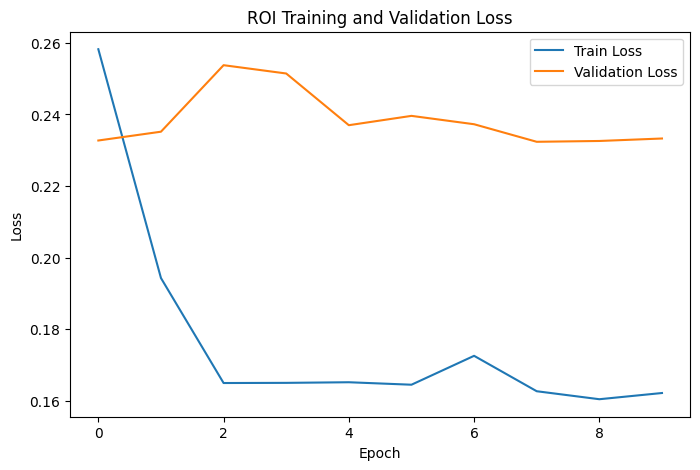

In [62]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_roi, label="Train Loss")
plt.plot(val_losses_roi, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ROI Training and Validation Loss")
plt.legend()
plt.show()